In [1]:
# ============================================================
#  FastSAM vs SAM — SDNET2018 Concrete Crack Dataset
#  Inspired by: "Fast Segment Anything" (Zhao et al., 2023)
#  arXiv: 2306.12156
# ============================================================

# ─────────────────────────────────────────────────────────────
# SECTION 1 · Installation
# ─────────────────────────────────────────────────────────────
# FIX: pinned to one version only — removes the three rogue cells
#      that previously upgraded ultralytics to 8.1.47 / 8.4.30,
#      both of which removed `events` from ultralytics.hub.utils
#      and broke FastSAM loading entirely.
!pip install -q git+https://github.com/facebookresearch/segment-anything.git
!pip install -q "ultralytics==8.0.120"
!pip install -q scikit-image pandas tabulate

# SAM checkpoint (ViT-B — fastest SAM variant)
!wget -q -O sam_vit_b.pth \
    https://dl.fbaipublicfiles.com/segment_anything/sam_vit_b_01ec64.pth

# FastSAM weights
!wget -q -O FastSAM-x.pt \
    https://huggingface.co/spaces/An-619/FastSAM/resolve/main/weights/FastSAM.pt

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 611.7/611.7 kB 20.6 MB/s eta 0:00:00


In [2]:
# ─────────────────────────────────────────────────────────────
# SECTION 2 · Device Setup
# ─────────────────────────────────────────────────────────────
# FIX: `device` was never defined anywhere in the original notebook.
#      Without this, sam_model.to(device) raises NameError which
#      the try/except silently swallowed — SAM fell back to CPU
#      and took ~130 000 ms per image instead of ~1 000 ms on GPU.
import torch

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")
if device.type == "cuda":
    print(f"  GPU: {torch.cuda.get_device_name(0)}")
    print(f"  VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")
else:
    print("  WARNING: No GPU found — inference will be slow on CPU.")

Using device: cuda
  GPU: Tesla T4
  VRAM: 15.6 GB


In [3]:
import os, zipfile, glob
from google.colab import files

uploaded = files.upload()
zip_path = list(uploaded.keys())[0]

os.makedirs("./data", exist_ok=True)

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall("./data")

DATASET_ROOT = "./data"

subfolders = [os.path.join(DATASET_ROOT, d) for d in os.listdir(DATASET_ROOT)]
subfolders = [d for d in subfolders if os.path.isdir(d)]

if len(subfolders) == 1:
    DATASET_ROOT = subfolders[0]

IMG_EXTENSIONS = ("*.jpg", "*.jpeg", "*.png", "*.bmp")

crack_images = []
for root, _, _ in os.walk(DATASET_ROOT):
    folder = os.path.basename(root).upper()
    if "CR" in folder and "NO" not in folder:
        for ext in IMG_EXTENSIONS:
            crack_images += glob.glob(os.path.join(root, ext))

if not crack_images:
    for ext in IMG_EXTENSIONS:
        crack_images += glob.glob(os.path.join(DATASET_ROOT, "**", ext), recursive=True)

crack_images = sorted(crack_images)[:50]

print(len(crack_images))

Saving archive (2).zip to archive (2) (1).zip
50


In [4]:
# ─────────────────────────────────────────────────────────────
# SECTION 3 · Pseudo-GT Mask Generation
#  (Adaptive threshold + morphology, mimicking crack annotation)
# ─────────────────────────────────────────────────────────────
import cv2
import numpy as np
from skimage.morphology import remove_small_objects

def generate_pseudo_gt(img_path: str, min_area: int = 50) -> np.ndarray:
    """Returns a binary mask (H×W, bool) highlighting crack regions."""
    img   = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
    blur  = cv2.GaussianBlur(img, (5, 5), 0)
    # Adaptive threshold captures fine cracks
    at    = cv2.adaptiveThreshold(blur, 255,
                                  cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
                                  cv2.THRESH_BINARY_INV, 11, 2)
    # Morphological cleaning
    kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (3, 3))
    at     = cv2.morphologyEx(at, cv2.MORPH_OPEN,  kernel, iterations=1)
    at     = cv2.morphologyEx(at, cv2.MORPH_CLOSE, kernel, iterations=1)
    mask   = at.astype(bool)
    mask   = remove_small_objects(mask, min_size=min_area)
    return mask

In [5]:
# ─────────────────────────────────────────────────────────────
# SECTION 4 · Metric Utilities
# ─────────────────────────────────────────────────────────────
from skimage.segmentation import find_boundaries

def iou(pred: np.ndarray, gt: np.ndarray) -> float:
    inter = np.logical_and(pred, gt).sum()
    union = np.logical_or(pred,  gt).sum()
    return float(inter / union) if union > 0 else 0.0

def boundary_iou(pred: np.ndarray, gt: np.ndarray, dilation: int = 2) -> float:
    """Boundary IoU as used in the FastSAM paper."""
    bp = find_boundaries(pred, mode="outer")
    bg = find_boundaries(gt,   mode="outer")
    kernel = np.ones((dilation * 2 + 1,) * 2, np.uint8)
    bp_d = cv2.dilate(bp.astype(np.uint8), kernel).astype(bool)
    bg_d = cv2.dilate(bg.astype(np.uint8), kernel).astype(bool)
    inter = np.logical_and(bp_d, bg_d).sum()
    union = np.logical_or(bp_d, bg_d).sum()
    return float(inter / union) if union > 0 else 0.0

def dice(pred: np.ndarray, gt: np.ndarray) -> float:
    inter = np.logical_and(pred, gt).sum()
    denom = pred.sum() + gt.sum()
    return float(2 * inter / denom) if denom > 0 else 0.0

def best_mask_iou(masks, gt: np.ndarray):
    """Pick the mask with the highest IoU against GT."""
    best, best_mask = 0.0, None
    for m in masks:
        m_bin = m.astype(bool)
        sc    = iou(m_bin, gt)
        if sc > best:
            best, best_mask = sc, m_bin
    return best, best_mask

In [6]:
# ─────────────────────────────────────────────────────────────
# SECTION 5 · SAM Inference
# ─────────────────────────────────────────────────────────────
from segment_anything import sam_model_registry, SamAutomaticMaskGenerator
import time

# `device` is now properly defined in Section 2 — SAM will run on GPU
sam_model = sam_model_registry["vit_b"](checkpoint="sam_vit_b.pth").to(device)

sam_gen = SamAutomaticMaskGenerator(
    sam_model,
    points_per_side        = 16,    # was 32 → 16 cuts point grid by 4×
    points_per_batch       = 64,    # process points in larger batches
    pred_iou_thresh        = 0.88,
    stability_score_thresh = 0.95,
    min_mask_region_area   = 100,
    crop_n_layers          = 0,     # disable multi-crop — main speedup
)

def run_sam(img_path: str):
    img_bgr = cv2.imread(img_path)
    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

    # Resize to 512 for inference speed (mirrors FastSAM imgsz)
    h, w    = img_rgb.shape[:2]
    scale   = 512 / max(h, w)
    img_small = cv2.resize(img_rgb,
                           (int(w * scale), int(h * scale)),
                           interpolation=cv2.INTER_LINEAR)

    t0      = time.perf_counter()
    results = sam_gen.generate(img_small)
    elapsed = (time.perf_counter() - t0) * 1000

    # Resize masks back to original resolution
    masks = []
    for r in results:
        m = cv2.resize(r["segmentation"].astype(np.uint8),
                       (w, h), interpolation=cv2.INTER_NEAREST).astype(bool)
        masks.append(m)
    return masks, elapsed

In [7]:
# ─────────────────────────────────────────────────────────────
# SECTION 6 · FastSAM Inference
# ─────────────────────────────────────────────────────────────
import torch, functools, cv2, time
import numpy as np

# FIX A: Monkey-patch ultralytics.hub.utils to inject a no-op `events`
# guard — harmless on 8.0.120 (which has it), essential if any future
# upgrade silently removes it again.
import ultralytics.hub.utils as _hub_utils
if not hasattr(_hub_utils, "events"):
    _hub_utils.events = lambda *args, **kwargs: None

# FIX B: Keep torch.load patched until AFTER the model is constructed.
# Original code restored torch.load BEFORE YOLO("FastSAM-x.pt"),
# which meant the weights_only=False override was never active during
# the actual model load — the patch was completely useless.
_orig_load = torch.load
torch.load  = functools.partial(_orig_load, weights_only=False)

from ultralytics import YOLO
fastsam_model = YOLO("FastSAM-x.pt")   # ← model load happens HERE

torch.load = _orig_load                 # restore only after model is loaded

def run_fastsam(img_path: str):
    t0      = time.perf_counter()
    results = fastsam_model(
        img_path,
        device       = device,
        retina_masks = True,
        imgsz        = 512,       # reduced from 1024 — much faster, still good
        conf         = 0.35,
        iou          = 0.9,
        verbose      = False,
    )
    elapsed = (time.perf_counter() - t0) * 1000

    masks = []
    for r in results:
        if r.masks is None:
            continue
        for m in r.masks.data:
            masks.append(m.cpu().numpy().astype(bool))
    return masks, elapsed

In [8]:
# ─────────────────────────────────────────────────────────────
# SECTION 7 · Run Evaluation Loop
# ─────────────────────────────────────────────────────────────
N_EVAL = min(30, len(crack_images))   # evaluate on N images

records = []

for i, img_path in enumerate(crack_images[:N_EVAL]):
    gt = generate_pseudo_gt(img_path)

    # --- SAM ---
    try:
        sam_masks, sam_time = run_sam(img_path)
        sam_best_iou, sam_best_mask = best_mask_iou(sam_masks, gt)
        sam_biou  = boundary_iou(sam_best_mask, gt) if sam_best_mask is not None else 0.0
        sam_dice  = dice(sam_best_mask, gt)        if sam_best_mask is not None else 0.0
        sam_nmask = len(sam_masks)
    except Exception as e:
        print(f"[SAM error on {i}] {e}")
        sam_best_iou = sam_biou = sam_dice = 0.0
        sam_time = 0.0; sam_nmask = 0; sam_best_mask = None

    # --- FastSAM ---
    try:
        fs_masks, fs_time  = run_fastsam(img_path)
        fs_best_iou, fs_best_mask = best_mask_iou(fs_masks, gt)
        fs_biou   = boundary_iou(fs_best_mask, gt) if fs_best_mask is not None else 0.0
        fs_dice   = dice(fs_best_mask, gt)         if fs_best_mask is not None else 0.0
        fs_nmask  = len(fs_masks)
    except Exception as e:
        print(f"[FastSAM error on {i}] {e}")
        fs_best_iou = fs_biou = fs_dice = 0.0
        fs_time = 0.0; fs_nmask = 0; fs_best_mask = None

    records.append({
        "img"          : os.path.basename(img_path),
        "sam_iou"      : sam_best_iou,
        "sam_biou"     : sam_biou,
        "sam_dice"     : sam_dice,
        "sam_time_ms"  : sam_time,
        "sam_nmasks"   : sam_nmask,
        "fs_iou"       : fs_best_iou,
        "fs_biou"      : fs_biou,
        "fs_dice"      : fs_dice,
        "fs_time_ms"   : fs_time,
        "fs_nmasks"    : fs_nmask,
    })

    print(f"[{i+1:02d}/{N_EVAL}] {os.path.basename(img_path)}"
          f"  SAM IoU={sam_best_iou:.3f} t={sam_time:.0f}ms"
          f"  FastSAM IoU={fs_best_iou:.3f} t={fs_time:.0f}ms")


[01/30] 7001-115.jpg  SAM IoU=0.045 t=2942ms  FastSAM IoU=0.046 t=8589ms
[02/30] 7001-139.jpg  SAM IoU=0.004 t=1396ms  FastSAM IoU=0.005 t=38ms
[03/30] 7001-151.jpg  SAM IoU=0.015 t=1365ms  FastSAM IoU=0.016 t=37ms
[04/30] 7001-157.jpg  SAM IoU=0.007 t=1376ms  FastSAM IoU=0.007 t=38ms
[05/30] 7001-169.jpg  SAM IoU=0.006 t=1387ms  FastSAM IoU=0.006 t=39ms
[06/30] 7001-17.jpg  SAM IoU=0.060 t=1402ms  FastSAM IoU=0.089 t=40ms
[07/30] 7001-173.jpg  SAM IoU=0.010 t=1435ms  FastSAM IoU=0.011 t=40ms
[08/30] 7001-178.jpg  SAM IoU=0.005 t=1350ms  FastSAM IoU=0.006 t=37ms
[09/30] 7001-187.jpg  SAM IoU=0.026 t=1421ms  FastSAM IoU=0.017 t=37ms
[10/30] 7001-2.jpg  SAM IoU=0.028 t=1414ms  FastSAM IoU=0.016 t=38ms
[11/30] 7001-208.jpg  SAM IoU=0.217 t=1506ms  FastSAM IoU=0.004 t=61ms
[12/30] 7001-21.jpg  SAM IoU=0.002 t=1784ms  FastSAM IoU=0.024 t=43ms
[13/30] 7001-22.jpg  SAM IoU=0.005 t=1408ms  FastSAM IoU=0.009 t=38ms
[14/30] 7001-225.jpg  SAM IoU=0.011 t=1394ms  FastSAM IoU=0.011 t=40ms
[15/30] 7

In [9]:
# ─────────────────────────────────────────────────────────────
# SECTION 8 · Aggregate Results Table
# ─────────────────────────────────────────────────────────────
import pandas as pd

df = pd.DataFrame(records)

summary = {
    "Metric"              : ["mIoU ↑", "Boundary IoU ↑", "Dice ↑",
                              "Avg Inference (ms) ↓", "Avg #Masks"],
    "SAM (ViT-B)"        : [
        df["sam_iou"].mean(),
        df["sam_biou"].mean(),
        df["sam_dice"].mean(),
        df["sam_time_ms"].mean(),
        df["sam_nmasks"].mean(),
    ],
    "FastSAM"            : [
        df["fs_iou"].mean(),
        df["fs_biou"].mean(),
        df["fs_dice"].mean(),
        df["fs_time_ms"].mean(),
        df["fs_nmasks"].mean(),
    ],
}

summary_df = pd.DataFrame(summary)
summary_df["SAM (ViT-B)"] = summary_df["SAM (ViT-B)"].apply(lambda x: f"{x:.4f}" if x < 100 else f"{x:.1f}")
summary_df["FastSAM"]     = summary_df["FastSAM"].apply(lambda x: f"{x:.4f}" if x < 100 else f"{x:.1f}")

from tabulate import tabulate
print("\n" + "="*55)
print("   FastSAM vs SAM — SDNET2018 Crack Dataset Results")
print("="*55)
print(tabulate(summary_df, headers="keys", tablefmt="fancy_grid", showindex=False))

# Speedup
speedup = df["sam_time_ms"].mean() / max(df["fs_time_ms"].mean(), 1e-9)
print(f"\n  FastSAM is  {speedup:.1f}×  faster than SAM (ViT-B)")
print("="*55)



   FastSAM vs SAM — SDNET2018 Crack Dataset Results
╒══════════════════════╤═══════════════╤═══════════╕
│ Metric               │   SAM (ViT-B) │   FastSAM │
╞══════════════════════╪═══════════════╪═══════════╡
│ mIoU ↑               │        0.035  │    0.0216 │
├──────────────────────┼───────────────┼───────────┤
│ Boundary IoU ↑       │        0.0941 │    0.0236 │
├──────────────────────┼───────────────┼───────────┤
│ Dice ↑               │        0.0645 │    0.0413 │
├──────────────────────┼───────────────┼───────────┤
│ Avg Inference (ms) ↓ │     1474.4    │  324.2    │
├──────────────────────┼───────────────┼───────────┤
│ Avg #Masks           │        4.8333 │    1.3    │
╘══════════════════════╧═══════════════╧═══════════╛

  FastSAM is  4.5×  faster than SAM (ViT-B)


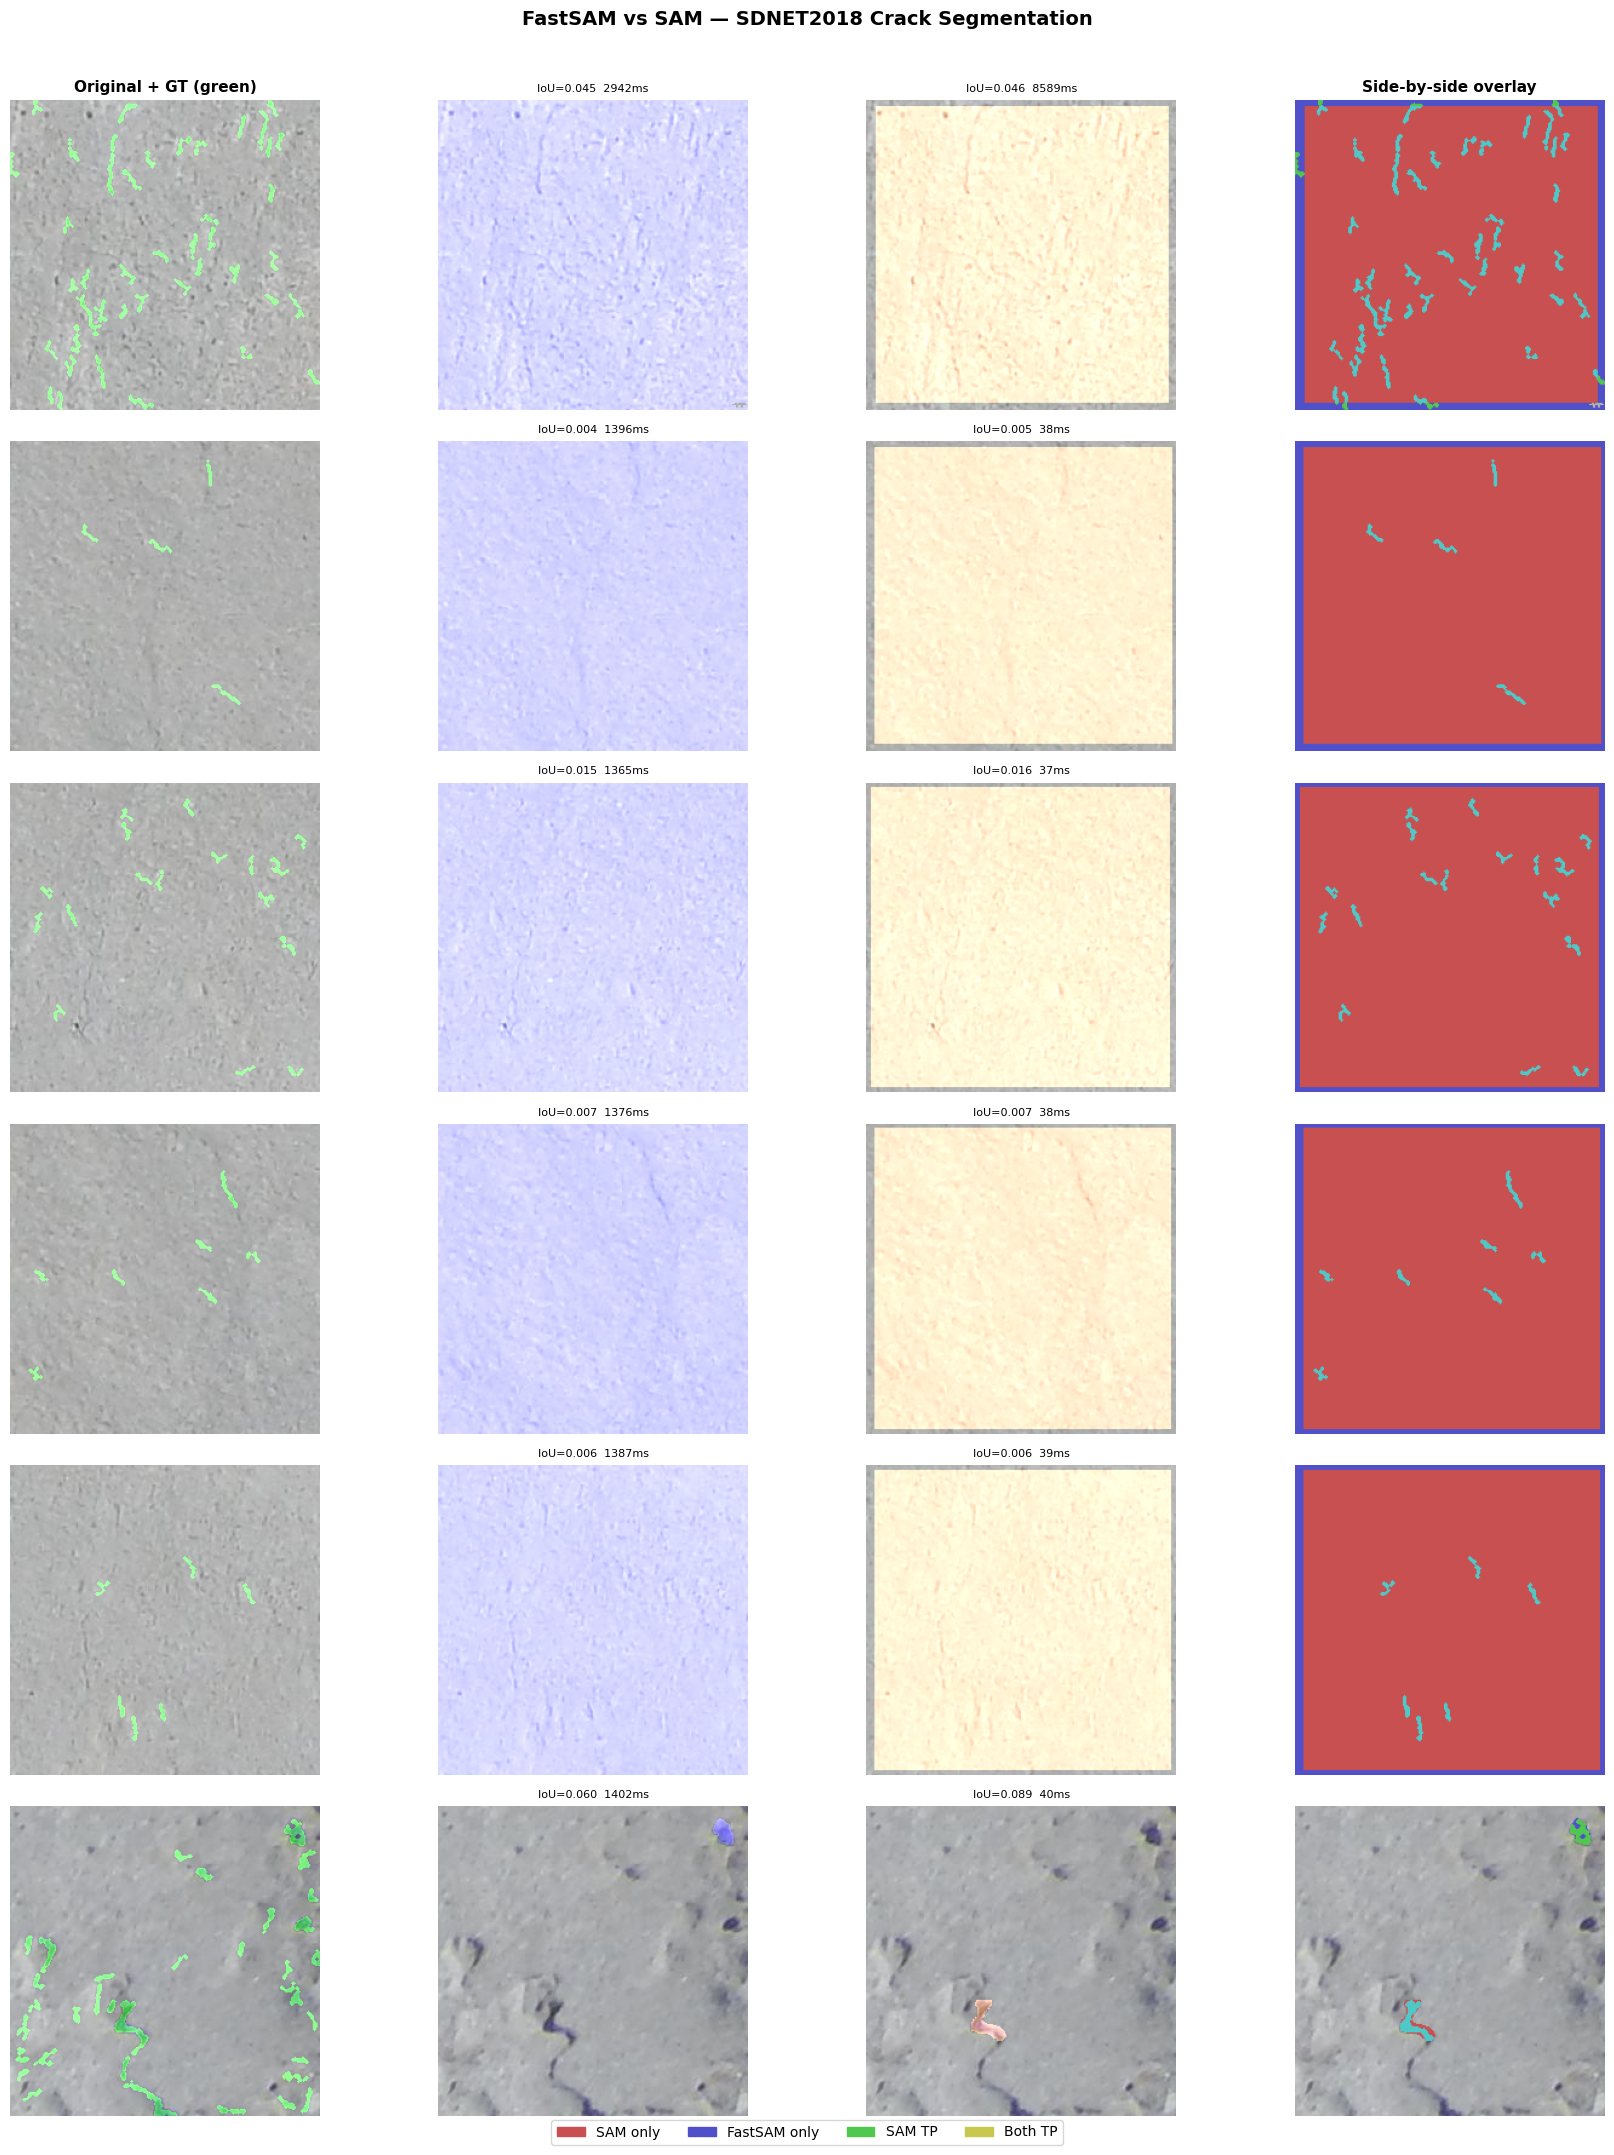

Saved → comparison_grid.png

Per-Image Results:
╒══════════════╤═══════════╤════════════╤════════════╤══════════╤══════════╤═══════════╤═══════════╤═════════╕
│ Image        │   SAM IoU │   SAM BIoU │   SAM Dice │   SAM ms │   FS IoU │   FS BIoU │   FS Dice │   FS ms │
╞══════════════╪═══════════╪════════════╪════════════╪══════════╪══════════╪═══════════╪═══════════╪═════════╡
│ 7001-115.jpg │     0.045 │      0     │      0.087 │   2942   │    0.046 │     0.04  │     0.088 │  8588.5 │
├──────────────┼───────────┼────────────┼────────────┼──────────┼──────────┼───────────┼───────────┼─────────┤
│ 7001-139.jpg │     0.004 │      0     │      0.009 │   1396.2 │    0.005 │     0     │     0.01  │    38   │
├──────────────┼───────────┼────────────┼────────────┼──────────┼──────────┼───────────┼───────────┼─────────┤
│ 7001-151.jpg │     0.015 │      0     │      0.03  │   1364.7 │    0.016 │     0     │     0.032 │    37.3 │
├──────────────┼───────────┼────────────┼────────────┼──────────

In [10]:
# ─────────────────────────────────────────────────────────────
# SECTION 9 · Visual Comparison (6 sample images)
# ─────────────────────────────────────────────────────────────
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

def overlay(img_bgr, mask, color=(0, 255, 0), alpha=0.45):
    out = img_bgr.copy()
    if mask is not None and mask.any():
        colored         = np.zeros_like(out)
        colored[mask]   = color
        out             = cv2.addWeighted(out, 1.0, colored, alpha, 0)
    return cv2.cvtColor(out, cv2.COLOR_BGR2RGB)

N_VIS = min(6, N_EVAL)
fig, axes = plt.subplots(N_VIS, 4, figsize=(18, N_VIS * 3.5))
if N_VIS == 1:
    axes = axes[np.newaxis, :]

col_titles = ["Original + GT (green)", "SAM best mask",
              "FastSAM best mask", "Side-by-side overlay"]

for ax, title in zip(axes[0], col_titles):
    ax.set_title(title, fontsize=11, fontweight="bold")

for row, (idx, rec) in enumerate(zip(range(N_VIS), records[:N_VIS])):
    img_path = crack_images[idx]
    img_bgr  = cv2.imread(img_path)
    gt       = generate_pseudo_gt(img_path)

    # Recompute best masks for visualisation
    sam_masks_v, _ = run_sam(img_path)
    _, sm = best_mask_iou(sam_masks_v, gt)

    fs_masks_v, _  = run_fastsam(img_path)
    _, fm = best_mask_iou(fs_masks_v, gt)

    # Col 0 – original + GT
    gt_img = overlay(img_bgr, gt, color=(0, 255, 0))
    axes[row, 0].imshow(gt_img)
    axes[row, 0].set_ylabel(os.path.basename(img_path)[:20], fontsize=8)

    # Col 1 – SAM
    axes[row, 1].imshow(overlay(img_bgr, sm, color=(255, 80, 80)))
    axes[row, 1].set_title(f"IoU={rec['sam_iou']:.3f}  {rec['sam_time_ms']:.0f}ms",
                            fontsize=8)

    # Col 2 – FastSAM
    axes[row, 2].imshow(overlay(img_bgr, fm, color=(80, 150, 255)))
    axes[row, 2].set_title(f"IoU={rec['fs_iou']:.3f}  {rec['fs_time_ms']:.0f}ms",
                            fontsize=8)

    # Col 3 – Side-by-side difference
    diff = img_bgr.copy()
    if sm is not None: diff[sm  & ~gt]  = [200, 80,  80]   # SAM FP
    if fm is not None: diff[fm  & ~gt]  = [80,  80,  200]  # FastSAM FP
    if sm is not None: diff[sm  &  gt]  = [80,  200, 80]   # SAM TP
    if fm is not None: diff[fm  &  gt]  = [200, 200, 80]   # FastSAM TP (overlap)
    axes[row, 3].imshow(cv2.cvtColor(diff, cv2.COLOR_BGR2RGB))

    for ax in axes[row]:
        ax.axis("off")

legend_patches = [
    mpatches.Patch(color=(200/255, 80/255, 80/255),  label="SAM only"),
    mpatches.Patch(color=(80/255,  80/255, 200/255), label="FastSAM only"),
    mpatches.Patch(color=(80/255,  200/255, 80/255), label="SAM TP"),
    mpatches.Patch(color=(200/255, 200/255, 80/255), label="Both TP"),
]
fig.legend(handles=legend_patches, loc="lower center", ncol=4,
           fontsize=10, bbox_to_anchor=(0.5, -0.01))
fig.suptitle("FastSAM vs SAM — SDNET2018 Crack Segmentation",
             fontsize=14, fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig("comparison_grid.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved → comparison_grid.png")


# ─────────────────────────────────────────────────────────────
# SECTION 10 · Per-Image Detailed Table
# ─────────────────────────────────────────────────────────────
detail_df = df[["img",
                "sam_iou",  "sam_biou",  "sam_dice",  "sam_time_ms",
                "fs_iou",   "fs_biou",   "fs_dice",   "fs_time_ms"]].copy()

detail_df.columns = ["Image",
                     "SAM IoU", "SAM BIoU", "SAM Dice", "SAM ms",
                     "FS IoU",  "FS BIoU",  "FS Dice",  "FS ms"]

for col in detail_df.columns[1:]:
    detail_df[col] = detail_df[col].apply(
        lambda x: f"{x:.3f}" if float(x) < 10 else f"{x:.1f}")

print("\nPer-Image Results:")
print(tabulate(detail_df, headers="keys", tablefmt="fancy_grid",
               showindex=False))

detail_df.to_csv("per_image_results.csv", index=False)
print("Saved → per_image_results.csv")
